In [7]:
import random

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas
import pandas as pd
import seaborn as sns
import yaml
from matplotlib.colors import ListedColormap
from sklearn import metrics
from sklearn.datasets import make_circles, make_blobs, make_classification, make_moons
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    average_precision_score,
    precision_recall_curve,
    f1_score
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.cluster import KMeans
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE

SEED = 314159
TRAIN_TEST_SPLIT = 0.80

data_path = "../../data/"

Рассмотрим набор данных о качестве вина на основе различных химических показателей. Есть всего 6 значений качества, поэтому задачу проще всего решать классификацией.

In [8]:
df = pd.read_csv(data_path+"winequality-red.csv", sep=",")

In [9]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


## Несбалансированные данные
Несбалансированные данные - это одна из наиболее распространенных проблем, с которой сталкиваются в машинном обучении. Они возникают, когда классы, которые мы пытаемся предсказать, представлены неравномерно. Другими словами, один класс имеет гораздо меньше примеров, чем другой, что создает дисбаланс в распределении данных.
Деревья решений очень уязвимы перед дисбалансом классов, так как используют вероятности в критериях разбиения.

**Задание**: Определите, сколько в датасете примеров хорошего вина (оценка 7 и выше) и плохого (3) в процентах от общего количества

In [10]:
y_binarized = (df['quality'] > 6).astype(int)
y_binarized_bad = (df['quality'] < 4).astype(int)


In [11]:
print(y_binarized.sum() / len(y_binarized))
print(y_binarized_bad.sum() / len(y_binarized))

0.1357098186366479
0.006253908692933083


**Задание**: Создайте новый признак "good_quality", чтобы выделить именно хорошее вино

In [12]:
good_quality = df['quality'] > 6
bad_quality = ~good_quality
y_binarized = good_quality.astype(int)


In [13]:
y_binarized = (df['quality'] > 6).astype(int)

In [14]:
X = df.drop('quality', axis=1)
y = df['quality']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
_, _, y_train_b, y_test_b = train_test_split(X, y_binarized, test_size=0.2, random_state=SEED)

model = DecisionTreeClassifier(random_state=0)
model.fit(X_train, y_train)
print("Train score is: ", model.score(X_train, y_train))
print("Test score is: ", model.score(X_test, y_test))

model_b = DecisionTreeClassifier(random_state=0)
model_b.fit(X_train, y_train_b)
print("Train score after binarization is: ", model_b.score(X_train, y_train_b))
print("Test score after binarization is: ", model_b.score(X_test, y_test_b))

Train score is:  1.0
Test score is:  0.640625
Train score after binarization is:  1.0
Test score after binarization is:  0.859375


Для работы с дисбалансом есть много методов. Вы наверняка слышали про взвешивание функции потерь, вероятно, что и про овер- или андерсемплинг тоже. Казалось бы - подбери хороший метод для оверсемплинга, аугментируй данные и радуйся. Но все же оказывается, что дисбаланс - тема более глубокая, чем может показаться на первый взгляд.

Дисбаланс - это естественное свойство. Проблемы заключаются не в самом дисбалансе как таковом, а в разных ступенях работы с данными. 

Например, самые неприятные проблемы - что классификатор начинает предсказывать константу. В таком случае дело в лоссе и пороге бинаризации или неправильно построенной валидации.

Если окаывается, что цена ошибки для одного из классов большая (в ту или иную сторону), то вопрос в корректном выборе метрик.
 
Может быть такое, что проблема в сдвиге распределений между обучающей выборкой и тестовой - тогда необходимо преобразовании процедуры валидации.


### Метрики
Так как данные несбалансированные, уместно ли использовать встроенное значение score для оценки модели? На самом деле, и да и нет, так как score возвращает усредненную точность по классам. Однако еще более информатиными будут F1-мера и другие более подробные оценки.
Формула Precision:
\begin{equation}
\text{Precision} = \frac{\text{TP}}{ \text{TP} + \text{FP} }
\end{equation}
Precision наиболее полезна, если цена FP велика. Примеры такой задачи - детекция спама. В случае, если полезное письмо попадет в спам, юзер может потерять важную информацию, что нежелательно.
Формула Recall:
\begin{equation}
\text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}}
\end{equation}
Recall наиболее полезна, если цена FN велика. Она поможет, если нам необходимо найти всех больных пациентов, определить фрод и т.д.
Вопрос: что отражают две эти метрики?


Формула F1-метрики:
\begin{equation}
\text{F1} = \frac{2 * \text{TP}}{2 * \text{TP} + \text{FP} + \text{FN}}
\end{equation}
F1-метрика может быть выведена из precision и recall и позволяет найти баланс между ними. 

**Задание**: определите, как f1 выводится из precision и recall.

Существует и болеее общая оценка - $F_\beta$. Она позволяет получить взвешенное среднее между precision и recall. Ее формулу дадим на занятии. Наиболее популярные параметры - 2 и 0.5.
Тут тоже есть особенности. Метрики бывают нескольких видов, в зависимости от того, как учитываются разные классы:
- микро - метрики считаются глобально сразу по всем классам.
- макро - вначале считаются для каждого класса, потом берется среднее ($F1_{macro} = \frac{1}{K}\sum_{k=1}^{K}F1_k$)
- взвешенные по классам - вначале считаются для каждого класса, потом берется среднее, взвешенное по поддержке

Вопрос: какой способ вычисления лучше всего выбрать при дисбалансе классов? Покажите на примере.

### Ответы на вопросы о метриках

**Что отражают Precision и Recall?**

- **Precision** (точность) = TP / (TP + FP) — из всех объектов, которые модель предсказала как позитивные,
  какая доля действительно позитивные? Отражает, насколько модель осторожна в положительных предсказаниях.
  Высокая precision -> мало ложных тревог.

- **Recall** (полнота) = TP / (TP + FN) — из всех реальных позитивных объектов,
  какую долю модель нашла? Отражает, насколько модель полна в охвате позитивного класса.
  Высокий recall -> мало пропущенных позитивных случаев.

---

**Как F1 выводится из Precision и Recall?**

Начнём с определения через матрицу ошибок:

$$F1 = \frac{2\,TP}{2\,TP + FP + FN}$$

Подставим $P = \dfrac{TP}{TP+FP}$ и $R = \dfrac{TP}{TP+FN}$, то есть $TP = P\cdot(TP+FP) = R\cdot(TP+FN)$.

Разделим числитель и знаменатель на $(TP+FP)(TP+FN)$:

$$F1 = \frac{\dfrac{2\,TP^2}{(TP+FP)(TP+FN)}}{TP\cdot\dfrac{(TP+FP)+(TP+FN)}{(TP+FP)(TP+FN)}} = \frac{2\,TP}{(TP+FP)+(TP+FN)} \cdot \frac{TP}{TP}$$

Заметим, что $\dfrac{TP}{TP+FP} = P$ и $\dfrac{TP}{TP+FN} = R$, поэтому:

$$F1 = \frac{2 \cdot P \cdot R}{P + R}$$

---

**Какой способ вычисления (micro / macro / weighted) лучше при дисбалансе?**

- **Micro** усредняет TP, FP, FN глобально по всем классам -> сильно зависит от мажоритарного класса.
  При дисбалансе практически совпадает с accuracy — не замечает проблем с редкими классами.

- **Macro** усредняет F1 по классам с равными весами -> каждый класс вносит одинаковый вклад.
  Строго наказывает за плохое качество на редких классах. **Лучший выбор при дисбалансе.**

- **Weighted** усредняет F1 по классам с весами, пропорциональными числу объектов -> снова даёт
  большой вес мажоритарному классу. Компромисс между micro и macro.

**Пример**: при 95% класса 0 и 5% класса 1 модель, предсказывающая всегда 0:
- micro F1 ≈ 0.90 (высокое — вводит в заблуждение)
- macro F1 ≈ 0.47 (честно отражает провал на классе 1)
- При дисбалансе -> смотреть macro F1.

### Синтетика: Fraud-like (минимизируем число пропусков)

Постановка: бинарная классификация транзакций, где мошенничество встречается редко. Пусть классы умеренно перекрываются, а `flip_y` имитирует ошибки в исторических данных. Нам важно не пропустить миноритарный класс.

Будем сравнивать модели, обученные без учета дисбаланса классов, и с учетом веса классов в функции потерь. 

In [15]:
from sklearn.ensemble import RandomForestClassifier


def evaluate_imbalance_models(
    X_train: np.ndarray,
    X_test: np.ndarray,
    y_train: np.ndarray,
    y_test: np.ndarray,
    model: str = "LR",
    thresholds: list[float] = [0.2, 0.5, 0.7],
    random_state: int = 42,
) -> tuple[pd.DataFrame, dict[str, np.ndarray]]:
    if model == "LR":
        model_class = LogisticRegression
    else:
        model_class = RandomForestClassifier
        
    models = {
        f"Baseline {model}": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", model_class(random_state=random_state)),
        ]),
        f"ClassWeight {model}": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", model_class(class_weight="balanced", random_state=random_state)),
        ]),

    }

    rows = []
    conf_mats = {}

    for model_name, model in models.items():
        model.fit(X_train, y_train)
        y_proba = model.predict_proba(X_test)[:, 1]

        for threshold in thresholds:
            pred_name = f"{model_name} (threshold={threshold})"
            y_pred = (y_proba >= threshold ).astype(int)
            rows.append(
                {
                    "model": pred_name,
                    "accuracy": accuracy_score(y_test, y_pred),
                    "precision": precision_score(y_test, y_pred, zero_division=0),
                    "recall": recall_score(y_test, y_pred, zero_division=0),
                    "f1_micro": f1_score(y_test, y_pred, average="micro", zero_division=0),
                    "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
                    "pr_auc": average_precision_score(y_test, y_proba),
                }
            )
            conf_mats[pred_name] = confusion_matrix(y_test, y_pred)

    result = pd.DataFrame(rows)  # .sort_values(["f1_macro", "recall"], ascending=False)
    return result.reset_index(drop=True), conf_mats

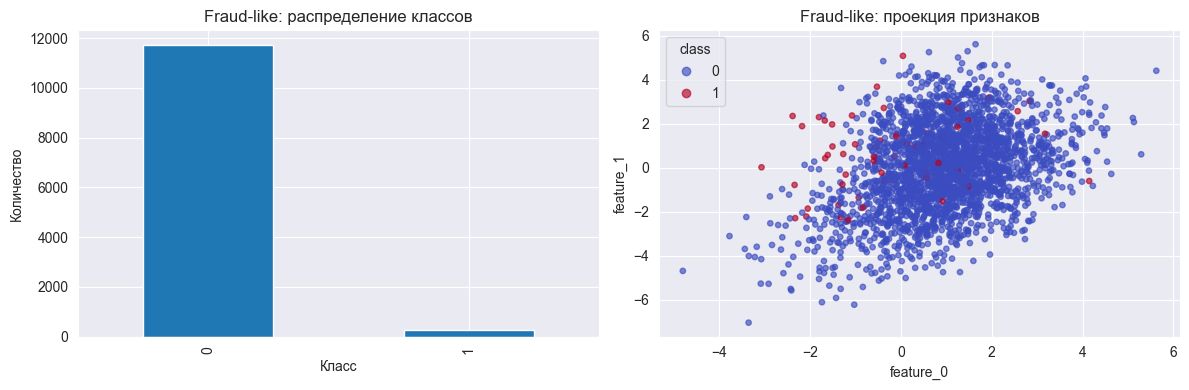

In [16]:
X_fraud, y_fraud = make_classification(
    n_samples=12000,
    n_features=10,
    n_informative=6,
    n_redundant=2,
    n_repeated=0,
    n_clusters_per_class=2,
    weights=[0.98, 0.02],
    class_sep=1.0,
    flip_y=0.01,
    random_state=SEED,
)

Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    X_fraud,
    y_fraud,
    test_size=0.25,
    stratify=y_fraud,
    random_state=SEED,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

pd.Series(y_fraud).value_counts().sort_index().plot(kind="bar", ax=axes[0])
axes[0].set_title("Fraud-like: распределение классов")
axes[0].set_xlabel("Класс")
axes[0].set_ylabel("Количество")

sample_idx = np.random.RandomState(SEED).choice(np.arange(len(X_fraud)), size=2500, replace=False)
scatter = axes[1].scatter(
    X_fraud[sample_idx, 0],
    X_fraud[sample_idx, 1],
    c=y_fraud[sample_idx],
    cmap="coolwarm",
    alpha=0.65,
    s=15,
)
axes[1].set_title("Fraud-like: проекция признаков")
axes[1].set_xlabel("feature_0")
axes[1].set_ylabel("feature_1")
axes[1].legend(*scatter.legend_elements(), title="class")

plt.tight_layout()
plt.show()


In [17]:

fraud_metrics, fraud_conf = evaluate_imbalance_models(Xf_train, Xf_test, yf_train, yf_test, "LR", random_state=SEED)
fraud_metrics

,model,accuracy,precision,recall,f1_micro,f1_macro,pr_auc
0,Baseline LR (threshold=0.2),0.976667,0.491228,0.405797,0.976667,0.716264,0.416434
1,Baseline LR (threshold=0.5),0.979667,0.722222,0.188406,0.979667,0.644267,0.416434
2,Baseline LR (threshold=0.7),0.979333,0.818182,0.130435,0.979333,0.607264,0.416434
3,ClassWeight LR (threshold=0.2),0.419667,0.036585,0.956522,0.419667,0.324310,0.321243
4,ClassWeight LR (threshold=0.5),0.844333,0.105159,0.768116,0.844333,0.549470,0.321243
5,ClassWeight LR (threshold=0.7),0.939667,0.214286,0.608696,0.939667,0.642710,0.321243


In [18]:

fraud_metrics, fraud_conf = evaluate_imbalance_models(Xf_train, Xf_test, yf_train, yf_test, "RF", random_state=SEED)
fraud_metrics

,model,accuracy,precision,recall,f1_micro,f1_macro,pr_auc
0,Baseline RF (threshold=0.2),0.981667,0.592105,0.652174,0.981667,0.805648,0.643508
1,Baseline RF (threshold=0.5),0.984000,0.956522,0.318841,0.984000,0.735068,0.643508
2,Baseline RF (threshold=0.7),0.980333,1.000000,0.144928,0.980333,0.621600,0.643508
3,ClassWeight RF (threshold=0.2),0.985000,0.676471,0.666667,0.985000,0.831929,0.630055
4,ClassWeight RF (threshold=0.5),0.980333,0.777778,0.202899,0.980333,0.655931,0.630055
5,ClassWeight RF (threshold=0.7),0.977333,1.000000,0.014493,0.977333,0.508552,0.630055


In [19]:
fraud_metrics[fraud_metrics["model"].map(lambda x: x.find("RF") > -1)]

,model,accuracy,precision,recall,f1_micro,f1_macro,pr_auc
0,Baseline RF (threshold=0.2),0.981667,0.592105,0.652174,0.981667,0.805648,0.643508
1,Baseline RF (threshold=0.5),0.984000,0.956522,0.318841,0.984000,0.735068,0.643508
2,Baseline RF (threshold=0.7),0.980333,1.000000,0.144928,0.980333,0.621600,0.643508
3,ClassWeight RF (threshold=0.2),0.985000,0.676471,0.666667,0.985000,0.831929,0.630055
4,ClassWeight RF (threshold=0.5),0.980333,0.777778,0.202899,0.980333,0.655931,0.630055
5,ClassWeight RF (threshold=0.7),0.977333,1.000000,0.014493,0.977333,0.508552,0.630055


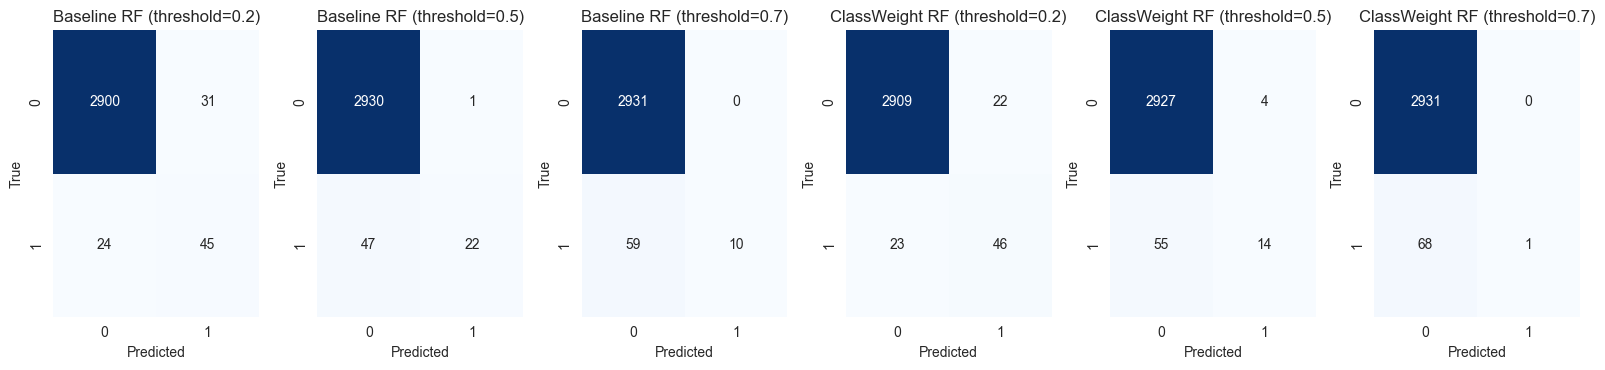

In [20]:
fig, axes = plt.subplots(1, len(fraud_conf), figsize=(16, 3.8))

for ax, model_name in zip(axes, fraud_conf.keys()):
    sns.heatmap(fraud_conf[model_name], annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(model_name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
plt.show()

Мы явно видим, что бейзлайн с высоким порогоим может иметь хороший `f1_micro`, но низкий `recall` . При снижении порога и/или балансировке (`class_weight`) recall растет, а вместе с ним и `f1_macro`, но возрастает число ложноположительных срабатываний. При этом попытка использовать балансировку классов приводит к очень большому числу ложных срабатываний (что хотя и не так плохо при наличии нескольких фильтров, может быть нежелательно). 

### Снова wine quality

In [21]:
print("Train f1-score is: ", f1_score(y_train, model.predict(X_train), average="micro"))
print("Test f1-score is: ", f1_score(y_test, model.predict(X_test), average="micro"))

Train f1-score is:  1.0
Test f1-score is:  0.640625


In [22]:
print("Train f1-score (binary) is: ", f1_score(y_train_b, model_b.predict(X_train), average="micro"))
print("Test f1-score  (binary) is: ", f1_score(y_test_b, model_b.predict(X_test), average="micro"))

Train f1-score (binary) is:  1.0
Test f1-score  (binary) is:  0.859375


In [23]:

print("Train f1-score is: ", f1_score(y_train, model.predict(X_train), average="macro"))
print("Test f1-score is: ", f1_score(y_test, model.predict(X_test), average="macro"))

Train f1-score is:  1.0
Test f1-score is:  0.4303156202512262


In [24]:
print("Train f1-score (binary) is: ", f1_score(y_train_b, model_b.predict(X_train), average="macro"))
print("Test f1-score (binary) is: ", f1_score(y_test_b, model_b.predict(X_test), average="macro"))

Train f1-score (binary) is:  1.0
Test f1-score (binary) is:  0.7311376239287515


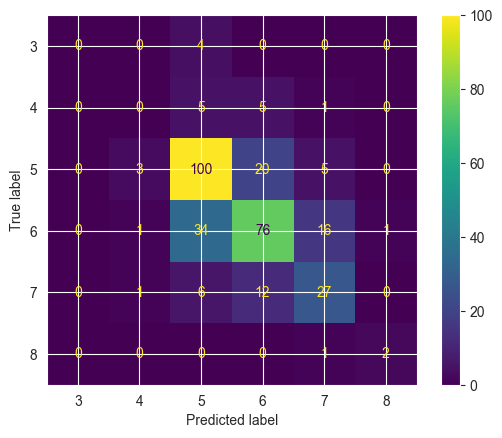

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.show()

Давайте руками рассмотрим, как оценивается точность и почему нам сложно получить адекватную оценку при сильном дисбалансе.

In [26]:
metrics_df = pd.DataFrame(columns=['label', 'TP', 'TN', 'FP', 'FN', 'support', 'accuracy', 'precision', 'recall'])

In [27]:
from sklearn.utils import compute_class_weight
classes = np.unique(y_train)
classes.sort()
print(classes)

[3 4 5 6 7 8]


In [28]:
y_pred = model.predict(X_test)

**Задание**: Закончите код для рассчета метрик по классам.

In [29]:
for class_id in classes:
    class_stats = {}
    gt = X_test.loc[y_test == class_id]
    class_stats['label'] = class_id
    class_stats['support'] = len(gt)

    # get model predictions for the whole test set
    y_pred = model.predict(X_test)

    # TP: predicted class_id AND actually class_id
    tp = int(((y_pred == class_id) & (y_test == class_id)).sum())
    # FP: predicted class_id but actually something else
    fp = int(((y_pred == class_id) & (y_test != class_id)).sum())
    # FN: actually class_id but predicted something else
    fn = int(((y_pred != class_id) & (y_test == class_id)).sum())
    # TN: not class_id and predicted not class_id
    tn = int(((y_pred != class_id) & (y_test != class_id)).sum())

    class_stats['TP'] = tp
    class_stats['FP'] = fp
    class_stats['FN'] = fn
    class_stats['TN'] = tn

    # Accuracy for this class (share of correctly classified objects)
    class_stats['accuracy'] = (tp + tn) / (tp + fp + fn + tn) if (tp + fp + fn + tn) > 0 else 0.0

    # Precision: of all predicted as class_id, how many are correct?
    class_stats['precision'] = tp / (tp + fp) if (tp + fp) > 0 else 0.0

    # Recall: of all actual class_id, how many did we catch?
    class_stats['recall'] = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    metrics_df = pd.concat(
        [metrics_df, pd.DataFrame(class_stats, index=[0])],
        ignore_index=True
    )


C:\Users\Roman\AppData\Local\Temp\ipykernel_18980\613849062.py:33: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df = pd.concat(


In [30]:
metrics_df

,label,TP,TN,FP,FN,support,accuracy,precision,recall
0,3,0,316,0,4,4,0.987500,0.000000,0.000000
1,4,0,304,5,11,11,0.950000,0.000000,0.000000
2,5,100,143,49,28,128,0.759375,0.671141,0.781250
3,6,76,155,37,52,128,0.721875,0.672566,0.593750
4,7,27,251,23,19,46,0.868750,0.540000,0.586957
5,8,2,316,1,1,3,0.993750,0.666667,0.666667


**Задание**: Посчитайте макро-метрики. 

**Задание со звездочкой**: Посчитайте микро-метрики. 

In [31]:
# Задание: макро- и микро-метрики вручную

y_pred = model.predict(X_test)

# ---- Macro metrics ----
# Считаем precision/recall/f1 для каждого класса, затем простое среднее

macro_precision_list = []
macro_recall_list    = []
macro_f1_list        = []

for class_id in classes:
    tp = int(((y_pred == class_id) & (y_test == class_id)).sum())
    fp = int(((y_pred == class_id) & (y_test != class_id)).sum())
    fn = int(((y_pred != class_id) & (y_test == class_id)).sum())

    p  = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    r  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0

    macro_precision_list.append(p)
    macro_recall_list.append(r)
    macro_f1_list.append(f1)

macro_precision = np.mean(macro_precision_list)
macro_recall    = np.mean(macro_recall_list)
macro_f1        = np.mean(macro_f1_list)

print('=== Макро-метрики (вручную) ===')
print(f'  Macro Precision : {macro_precision:.4f}')
print(f'  Macro Recall    : {macro_recall:.4f}')
print(f'  Macro F1        : {macro_f1:.4f}')

# Проверка через sklearn
from sklearn.metrics import precision_score, recall_score, f1_score
print(f'  sklearn macro F1: {f1_score(y_test, y_pred, average="macro"):.4f}')

# ---- Micro metrics (*) ----
# Суммируем TP, FP, FN глобально по всем классам, затем считаем метрики

micro_tp = sum(((y_pred == c) & (y_test == c)).sum() for c in classes)
micro_fp = sum(((y_pred == c) & (y_test != c)).sum() for c in classes)
micro_fn = sum(((y_pred != c) & (y_test == c)).sum() for c in classes)

micro_precision = micro_tp / (micro_tp + micro_fp) if (micro_tp + micro_fp) > 0 else 0.0
micro_recall    = micro_tp / (micro_tp + micro_fn) if (micro_tp + micro_fn) > 0 else 0.0
micro_f1        = (2 * micro_precision * micro_recall /
                   (micro_precision + micro_recall)
                   if (micro_precision + micro_recall) > 0 else 0.0)

print()
print('=== Микро-метрики (*) (вручную) ===')
print(f'  Micro Precision : {micro_precision:.4f}')
print(f'  Micro Recall    : {micro_recall:.4f}')
print(f'  Micro F1        : {micro_f1:.4f}')
print(f'  sklearn micro F1: {f1_score(y_test, y_pred, average="micro"):.4f}')


=== Макро-метрики (вручную) ===
  Macro Precision : 0.4251
  Macro Recall    : 0.4381
  Macro F1        : 0.4303
  sklearn macro F1: 0.4303

=== Микро-метрики (*) (вручную) ===
  Micro Precision : 0.6406
  Micro Recall    : 0.6406
  Micro F1        : 0.6406
  sklearn micro F1: 0.6406


F-мера позволяет сравнивать между собой модели, используя лишь одно число. Однако она и подобные ей метрики не всегда верно отражают действительность (мы уже частично это поняли). Но важно, что они могут расти больше из-за того, что прогнозы становятся нетривиальными! Например, пусть у нас есть 2 ящика, в каждом из них по 9 груш и 1 яблоку. Мы вытаскиваем за ход один фрукт из случайного ящика. Нам нужно угадать, какой это будет фрукт. Тогда, допустим:
1) Маша всегда говорит, что фрукт - груша. Точность такого прогноза - $0.5*0.9 + 0.5*0.9 = 0.9$. F1 при этом будет равна 0 (почему мы не гооврим про микро- и макро- случаи здесь?)
2) Вася говорит, что фрукт из первого ящика - груша, а из второго - яблоко. Точность такого прогноза - $0.5*0.9 + 0.5*0.1 = 0.5$. F1 будет уже $2 \over {2 + 9 + 1} = 0.166$

Оба не умеют угадывать фрукт, но Вася при этом выигрывает :(



### Ответ: почему не говорим про micro/macro для Маши?

У **Маши** всегда предсказывается один и тот же класс («груша»). Она не предсказывает «яблоко» ни разу. Поэтому для класса «яблоко» TP = 0, и precision и recall для него равны 0. F1 для яблока = 0.

Это делает вопрос micro/macro неважным в данном примере:
- **Macro F1** = среднее (F1_груша + F1_яблоко) / 2. F1_груша > 0, F1_яблоко = 0 → macro F1 > 0 но < 1.
  Однако в задаче нас интересует *польза* предсказания — а Маша вообще не распознаёт яблоки.
- **Micro F1** ≈ accuracy ≈ 0.9 — выглядит хорошо, но обманчиво.

Суть примера в другом: **метрики растут не только от улучшения модели, но и от того, что модель начинает давать хотя бы нетривиальные (ненулевые) предсказания на редком классе.** Вася хуже угадывает в целом, но получает ненулевой F1 — и это может ввести в заблуждение. Поэтому при дисбалансе важно смотреть на метрики *отдельно по классам* вместе с support.

## Imbalanced learning

Как заставить модель учиться так, чтобы учитывать все классы? Самое простое - задать вес класса. Мы уже проделали это на синтетике, проделаем и на датасете по вину.

In [32]:
X = df.drop('quality', axis=1)
y = df['quality']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
_, _, y_train_b, y_test_b = train_test_split(X, y_binarized, test_size=0.2, random_state=SEED)

model = RandomForestClassifier(random_state=0)
model.fit(X_train, y_train)
print("Train score is: ", model.score(X_train, y_train))
print("Test score is: ", model.score(X_test, y_test))

model_b = RandomForestClassifier(random_state=0)
model_b.fit(X_train, y_train_b)
print("Train score after binarization is: ", model_b.score(X_train, y_train_b))
print("Test score after binarization is: ", model_b.score(X_test, y_test_b))

Train score is:  1.0
Test score is:  0.678125
Train score after binarization is:  1.0
Test score after binarization is:  0.9


Вопрос: Какие есть хорошие способы это сделать?

### Ответ: хорошие способы задать веса классов

**1. Обратно пропорционально частоте** (inverse frequency):
$$w_k = \frac{N}{K \cdot N_k}$$
где $N$ — всего объектов, $K$ — число классов, $N_k$ — число объектов класса $k$.

**2. Корень из обратной частоты** (сглаженный вариант):
$$w_k = \sqrt{\frac{N}{N_k}}$$
Менее агрессивен — не так сильно усиливает редкие классы.

**3. Вручную по доменным знаниям:**
Например, ошибка на фроде в 10 раз дороже, чем на норме → `class_weight={0: 1, 1: 10}`.

**4. `class_weight='balanced'` в sklearn** — автоматически вычисляет $N / (K \cdot N_k)$ для каждого класса.

In [33]:
n_classes = len(classes)
class_weights = [
    len(X_train) / (n_classes * len(X_train.loc[y_train == class_id]))
    for class_id in classes
]
print('Веса классов:')
for c, w in zip(classes, class_weights):
    n_c = len(X_train.loc[y_train == c])
    print(f'  class {c}: {n_c:4d} объектов -> weight = {w:.3f}')

model = RandomForestClassifier(
    class_weight={classes[i]: w for i, w in enumerate(class_weights)},
    random_state=0
)
model.fit(X_train, y_train)
print('Train score is: ', model.score(X_train, y_train))
print('Test score is:  ', model.score(X_test, y_test))


Веса классов:
  class 3:    6 объектов -> weight = 35.528
  class 4:   42 объектов -> weight = 5.075
  class 5:  553 объектов -> weight = 0.385
  class 6:  510 объектов -> weight = 0.418
  class 7:  153 объектов -> weight = 1.393
  class 8:   15 объектов -> weight = 14.211
Train score is:  1.0
Test score is:   0.671875


In [34]:
class_weights

[35.52777777777778,
 5.075396825396825,
 0.38547317661241715,
 0.41797385620915034,
 1.3932461873638344,
 14.21111111111111]

In [35]:
model_b = RandomForestClassifier(class_weight={i: len(X_train)/len(X_train.loc[y_train_b==i]) for i in [0,1]}, random_state=0)
model_b.fit(X_train, y_train_b)
print("Train score is: ", model_b.score(X_train, y_train_b))
print("Test score is: ", model_b.score(X_test, y_test_b))

Train score is:  1.0
Test score is:  0.89375


In [36]:
print("Train micro f1-score is: ", f1_score(y_train, model.predict(X_train), average="micro"))
print("Test micro f1-score is: ", f1_score(y_test, model.predict(X_test), average="micro"))
print("Train macro f1-score is: ", f1_score(y_train, model.predict(X_train), average="macro"))
print("Test macro f1-score is: ", f1_score(y_test, model.predict(X_test), average="macro"))

Train micro f1-score is:  1.0
Test micro f1-score is:  0.671875
Train macro f1-score is:  1.0
Test macro f1-score is:  0.33289615921297794


In [37]:
print("Train micro (binary) f1-score is: ", f1_score(y_train_b, model_b.predict(X_train), average="micro"))
print("Test micro (binary) f1-score is: ", f1_score(y_test_b, model_b.predict(X_test), average="micro"))
print("Train macro (binary) f1-score is: ", f1_score(y_train_b, model_b.predict(X_train), average="macro"))
print("Test macro (binary) f1-score is: ", f1_score(y_test_b, model_b.predict(X_test), average="macro"))

Train micro (binary) f1-score is:  1.0
Test micro (binary) f1-score is:  0.89375
Train macro (binary) f1-score is:  1.0
Test macro (binary) f1-score is:  0.7461739455020531


Выведем, как изменились предсказания модели.

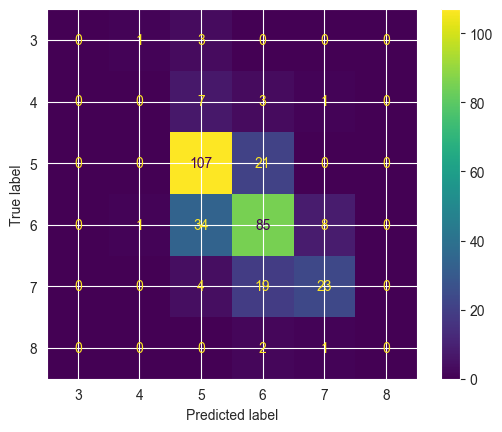

In [38]:
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.show()

In [39]:
# Создаём сводную таблицу метрик: модель без весов vs с весами (мультикласс)
from sklearn.metrics import f1_score, classification_report

model_plain = RandomForestClassifier(max_depth=5, random_state=0)
model_plain.fit(X_train, y_train)

model_weighted = RandomForestClassifier(
    class_weight={classes[i]: w for i, w in enumerate(class_weights)},
    random_state=0
)
model_weighted.fit(X_train, y_train)

y_pred_plain    = model_plain.predict(X_test)
y_pred_weighted = model_weighted.predict(X_test)

rows = []
for class_id in classes:
    for model_name, y_pred in [('Без весов', y_pred_plain), ('С весами', y_pred_weighted)]:
        tp = int(((y_pred == class_id) & (y_test == class_id)).sum())
        fp = int(((y_pred == class_id) & (y_test != class_id)).sum())
        fn = int(((y_pred != class_id) & (y_test == class_id)).sum())
        p  = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        r  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
        rows.append({'model': model_name, 'class': class_id,
                     'support': int((y_test == class_id).sum()),
                     'precision': round(p, 3), 'recall': round(r, 3), 'f1': round(f1, 3)})

display(pd.DataFrame(rows))

print()
print('=== Macro F1 ===')
print(f'  Без весов : {f1_score(y_test, y_pred_plain,    average="macro"):.4f}')
print(f'  С весами  : {f1_score(y_test, y_pred_weighted, average="macro"):.4f}')
print()
print('=== Classification report (с весами) ===')
print(classification_report(y_test, y_pred_weighted))


,model,class,support,precision,recall,f1
0,Без весов,3,4,0.000,0.000,0.000
1,С весами,3,4,0.000,0.000,0.000
2,Без весов,4,11,0.000,0.000,0.000
3,С весами,4,11,0.000,0.000,0.000
4,Без весов,5,128,0.654,0.797,0.718
5,С весами,5,128,0.690,0.836,0.756
6,Без весов,6,128,0.557,0.648,0.599
7,С весами,6,128,0.654,0.664,0.659
8,Без весов,7,46,0.733,0.239,0.361
9,С весами,7,46,0.697,0.500,0.582



=== Macro F1 ===
  Без весов : 0.2797
  С весами  : 0.3329

=== Classification report (с весами) ===
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00        11
           5       0.69      0.84      0.76       128
           6       0.65      0.66      0.66       128
           7       0.70      0.50      0.58        46
           8       0.00      0.00      0.00         3

    accuracy                           0.67       320
   macro avg       0.34      0.33      0.33       320
weighted avg       0.64      0.67      0.65       320



C:\Users\Roman\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Roman\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Roman\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

Также посмотрим, насколько чувствительна к дисбалансу другая модель - LogisticRegression

In [40]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


In [41]:
logreg = make_pipeline(StandardScaler(), LogisticRegression()) # make pipeline of Scaler and Logreg
logreg.fit(X_train, y_train)
print("Naive train score is: ", logreg.score(X_train, y_train))
print("Naive test score is: ", logreg.score(X_test, y_test))
print("Classes", logreg.classes_)

Naive train score is:  0.6106333072713057
Naive test score is:  0.596875
Classes [3 4 5 6 7 8]


In [42]:
logreg = make_pipeline(StandardScaler(), LogisticRegression(class_weight={i: len(X_train)/len(X_train.loc[y_train==i]) for i in [3, 4, 5, 6, 7, 8]})) # make pipeline of Scaler and Logreg with class weights
logreg.fit(X_train, y_train)
print("Balanced train score is: ", logreg.score(X_train, y_train))
print("Balanced test score is: ", logreg.score(X_test, y_test))

Balanced train score is:  0.44566067240031276
Balanced test score is:  0.446875


Как видно, балансировка не всегда одинаково полезна. Однако мы можем попробовать воспользоваться дополнительными методами для обучения нашей модели. Это будет андер- и оверсемплинг (балансировка датасета). Идея балансировки данных проста - мы делаем классы сбалансированными, либо заменяя большой класс подвыборкой, близкой к  малому классу, либо же увеличиваем в размерах малый класс с помощью синтетики.


Самое простое - взять только небольшую, но сбалансированную часть обучающих данных для непосредственного обучения, взяв случайную подвыборку большрого класса. Однако, для нашего случая это плохо подходит, так как данных довольно мало. (На самом деле, даже в такой ситуации это может быть полезно, чтобы обучить ансамбли моделей, обученных на разных обрезанных выборках). В случае же оверсемплинга самый простой способ - продублировать объекты малого класса.

Еще раз вспомним, какие предсказания давал случайный лес для нашего набора

In [43]:
model = RandomForestClassifier(max_depth=5)
model.fit(X_train, y_train)
print("Train score is: ", model.score(X_train, y_train))
print("Test score is: ", model.score(X_test, y_test))

print("Train f1-score is: ", f1_score(y_train, y_pred=model.predict(X_train), average="macro"))
print("Test f1-score is: ", f1_score(y_test, y_pred=model.predict(X_test), average="macro"))

Train score is:  0.6989835809225958
Test score is:  0.6125
Train f1-score is:  0.32494679046786873
Test f1-score is:  0.27249018243808615


# Оверсемплинг

Для начала проведем простейший оверсемплинг, выбирая семплы из минорного класса с заменой до достижения баланса:

In [44]:
def print_counts(y) -> None:
    unique, counts = np.unique(y, return_counts=True)
    print("\n".join([f"{u}: {c}" for u, c in zip(unique, counts)]))

In [45]:
print_counts(y_train) 

3: 6
4: 42
5: 553
6: 510
7: 153
8: 15


In [46]:
ros = RandomOverSampler(random_state=SEED, ) # choose your parameters
X_res, y_res = ros.fit_resample(X_train, y_train)
model = RandomForestClassifier(max_depth=5)
model.fit(X_res, y_res)
print("Train score is: ", model.score(X_res, y_res))
print("Test score is: ", model.score(X_test, y_test))
print("Test f1-score is: ", f1_score(y_test, y_pred=model.predict(X_test), average="macro"))
print_counts(y_res)

Train score is:  0.7914406268836649
Test score is:  0.515625
Test f1-score is:  0.2997985908551331
3: 553
4: 553
5: 553
6: 553
7: 553
8: 553


### SMOTE (Synthetic Minority Oversampling Technique):
SMOTE позволяет расширить выборку, построив синтетические примеры на основе уже существующих. Это еще один вариант решения «проблем классового дисбаланса». Подобный алгоритм используется в некоторых методах аугментации, например, MixUp.

Общая схема SMOTE:
1) Для создания нового семпла используют пару признаков «соседних» примеров a  и b из миноритарного класса. Их находят, используя KNN. В данном случае достаточно для семпла a получить набор из k соседей, из которого в дальнейшем будет случайно выбран семпл b.
2) Для создания нового семпла находят разность $d=X_b–X_a$, где $X_a,X_b$ – векторы признаков «соседних» примеров a  и b из миноритарного класса.
3) Далее из $d$ путем его умножения на случайное число в интервале (0,1)  получают $d'$.
4) Вектор признаков нового примера вычисляется путем сложения Xa и $d'$.

Вопрос: сколько соседей выбирать? И сколько соседей стоит использовать для каждой узловой точки?


In [47]:
# k_neighbors=5 — стандартное значение: достаточно велико, чтобы покрыть
# окрестность, но не настолько велико, чтобы интерполировать в область
# мажоритарного класса. Для каждой узловой точки выбирается 1 случайный
# сосед из k, что обеспечивает разнообразие синтетики.

# sampling_strategy='minority' — досэмплируем только наименьший класс
# до размера второго по величине класса.
smote = SMOTE(random_state=SEED, k_neighbors=5, sampling_strategy='minority') # choose your parameters
X_res, y_res = smote.fit_resample(X_train, y_train)
print_counts(y_res)

3: 553
4: 42
5: 553
6: 510
7: 153
8: 15


In [48]:
model = RandomForestClassifier(max_depth=5)
model.fit(X_res, y_res)
print("Train score is: ", model.score(X_res, y_res))
print("Test score is: ", model.score(X_test, y_test))
print("Test f1-score is: ", f1_score(y_test, y_pred=model.predict(X_test), average="macro"))

Train score is:  0.7699890470974808
Test score is:  0.59375
Test f1-score is:  0.25662247838242364


Также мы можем получить более подробный отчет по точности модели.

In [49]:
from imblearn.metrics import classification_report_imbalanced

In [50]:
print(classification_report_imbalanced(y_test, model.predict(X_test)))

                   pre       rec       spe        f1       geo       iba       sup

          3       0.00      0.00      0.97      0.00      0.00      0.00         4
          4       0.00      0.00      1.00      0.00      0.00      0.00        11
          5       0.64      0.77      0.71      0.70      0.74      0.55       128
          6       0.56      0.66      0.66      0.61      0.66      0.44       128
          7       1.00      0.13      1.00      0.23      0.36      0.12        46
          8       0.00      0.00      1.00      0.00      0.00      0.00         3

avg / total       0.62      0.59      0.75      0.56      0.61      0.41       320



C:\Users\Roman\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Рассмотрим также поведение алгоритма на синтетических данных.

### Сравнение методов over/under sampling на wine


In [51]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
import pandas as pd
import numpy as np

from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN, BorderlineSMOTE
from imblearn.under_sampling import RandomUnderSampler, NearMiss, TomekLinks, EditedNearestNeighbours

X_tr, y_tr, X_te, y_te = X_train, y_train_b, X_test, y_test_b
minority = int(np.min(np.bincount(np.asarray(y_tr))))
k = max(1, min(3, minority - 1))

methods = {
    'Over:RandomOverSampler': RandomOverSampler(random_state=SEED),
    'Over:SMOTE': SMOTE(random_state=SEED, k_neighbors=k),
    'Over:AdaSYN': ADASYN(random_state=SEED, n_neighbors=k),
    'Over:BorderlineSMOTE': BorderlineSMOTE(random_state=SEED, k_neighbors=k),
    'Under:RandomUnderSampler': RandomUnderSampler(random_state=SEED),
    'Under:NearMiss': NearMiss(version=1, n_neighbors=k),
    'Under:TomekLinks': TomekLinks(),
    'Under:EditedNearestNeighbours': EditedNearestNeighbours(n_neighbors=k)
}

rows = []
for name, sampler in methods.items():
    X_res, y_res = sampler.fit_resample(X_tr, y_tr)
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, random_state=SEED))
    clf.fit(X_res, y_res)
    pred = clf.predict(X_te)
    rows.append((name, f1_score(y_te, pred, average='macro'), f1_score(y_te, pred, average='micro')))

pd.DataFrame(rows, columns=['method', 'f1_macro', 'f1_micro']).sort_values('f1_macro', ascending=False)


,method,f1_macro,f1_micro
1,Over:SMOTE,0.701317,0.796875
0,Over:RandomOverSampler,0.698192,0.784375
4,Under:RandomUnderSampler,0.689424,0.781250
2,Over:AdaSYN,0.686495,0.778125
3,Over:BorderlineSMOTE,0.685894,0.787500
7,Under:EditedNearestNeighbours,0.670228,0.821875
6,Under:TomekLinks,0.664306,0.850000
5,Under:NearMiss,0.515670,0.575000


Задание: Проанализируйте также поведение на make_moons. Сделайте выводы.

Баланс классов: class 0 = 500, class 1 = 55


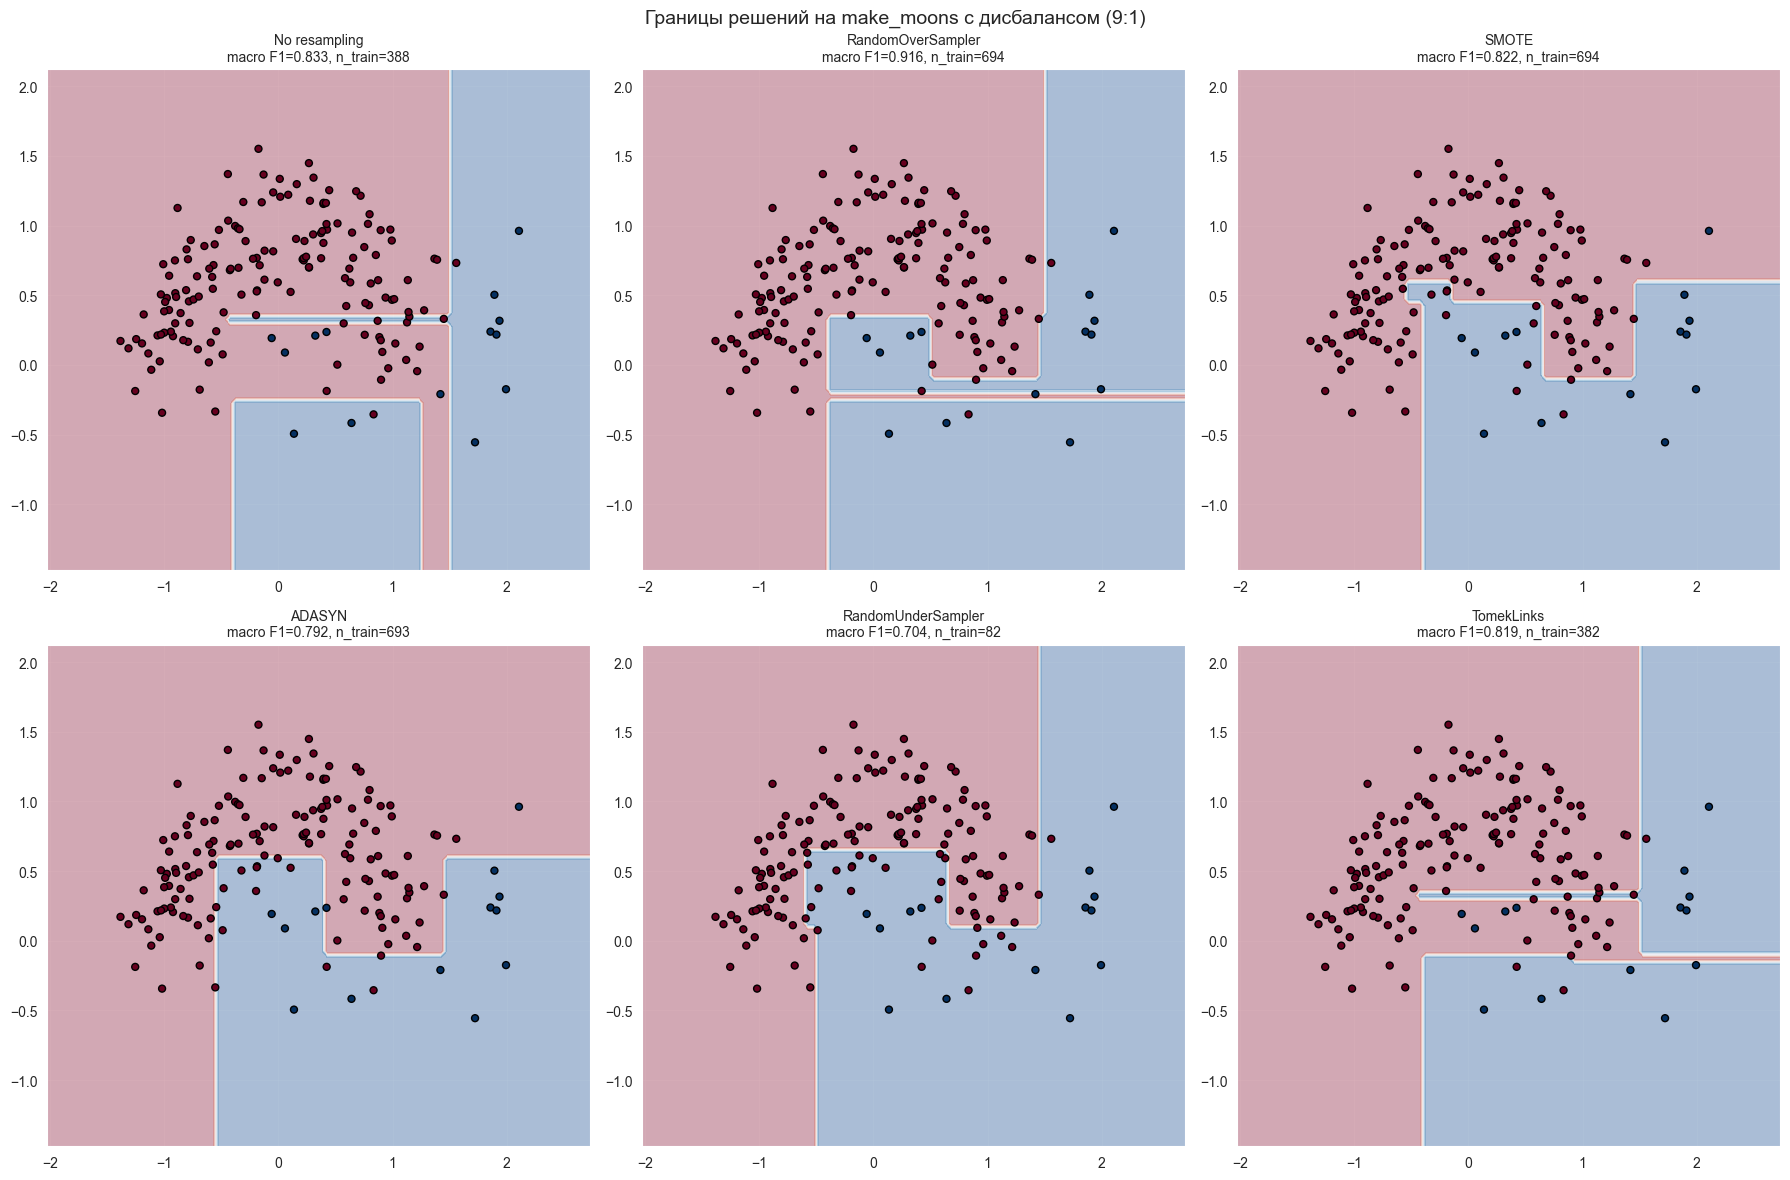

In [52]:
# Задание: анализ поведения методов семплинга на make_moons
from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier

np.random.seed(SEED)
X_moons, y_moons = make_moons(n_samples=1000, noise=0.25, random_state=SEED)

# Создаём дисбаланс: оставляем 90% класса 0, 10% класса 1
idx_0 = np.where(y_moons == 0)[0]
idx_1 = np.where(y_moons == 1)[0]
idx_1_keep = np.random.choice(idx_1, size=len(idx_1) // 9, replace=False)
keep = np.concatenate([idx_0, idx_1_keep])
X_imb, y_imb = X_moons[keep], y_moons[keep]

print(f'Баланс классов: class 0 = {(y_imb==0).sum()}, class 1 = {(y_imb==1).sum()}')

X_tr, X_te, y_tr, y_te = train_test_split(X_imb, y_imb, test_size=0.3, random_state=SEED)
k_nb = max(1, min(3, (y_tr == 1).sum() - 1))

samplers = {
    'No resampling':    None,
    'RandomOverSampler': RandomOverSampler(random_state=SEED),
    'SMOTE':            SMOTE(random_state=SEED, k_neighbors=k_nb),
    'ADASYN':           ADASYN(random_state=SEED, n_neighbors=k_nb),
    'RandomUnderSampler': RandomUnderSampler(random_state=SEED),
    'TomekLinks':       TomekLinks(),
}

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Границы решений на make_moons с дисбалансом (9:1)', fontsize=14)

for ax, (name, sampler) in zip(axes.ravel(), samplers.items()):
    if sampler is not None:
        Xr, yr = sampler.fit_resample(X_tr, y_tr)
    else:
        Xr, yr = X_tr, y_tr

    clf = DecisionTreeClassifier(max_depth=5, random_state=SEED)
    clf.fit(Xr, yr)

    # Решётка для отображения границы
    h = 0.05
    x_min, x_max = X_imb[:, 0].min() - 0.5, X_imb[:, 0].max() + 0.5
    y_min, y_max = X_imb[:, 1].min() - 0.5, X_imb[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    ax.scatter(X_te[:, 0], X_te[:, 1], c=y_te, cmap='RdBu', edgecolors='k', s=25)

    f1_mac = f1_score(y_te, clf.predict(X_te), average='macro')
    n_res  = len(yr)
    ax.set_title(f'{name}\nmacro F1={f1_mac:.3f}, n_train={n_res}', fontsize=10)
    ax.grid(True, alpha=0.2)

plt.tight_layout(); plt.show()


In [53]:
X_gen, y_gen = make_classification(n_samples=5000, n_features=2, n_informative=2,
                           n_redundant=0, n_repeated=0, n_classes=3,
                           n_clusters_per_class=1,
                           weights=[0.02, 0.05, 0.94],
                           class_sep=0.8, random_state=SEED)
X_train, X_test, y_train, y_test = train_test_split(X_gen, y_gen) # train test split

ros = RandomOverSampler(random_state=SEED)
X_resampled, y_resampled = ros.fit_resample(X_train, y_train)


In [54]:
def plot_decision_function(X, y, clf, ax):
    plot_step = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.4)

In [55]:
X_train

array([[ 1.16190811, -0.95653374],
       [ 0.21317259,  0.15750382],
       [ 0.77492924, -1.99954479],
       ...,
       [ 1.41858979, -0.20283288],
       [ 1.33821451, -1.03475261],
       [ 1.42981935, -0.48859749]])

In [56]:
# Choosing the first 2 columns for the plot

def get_decision_boundary(X_train, y_train, features, ax=None, model="logistic"):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8,8))
    # Creating and fitting the tree classifier
    if model == "logistic":
        classifier = LogisticRegression() # your code: 
    else:
        classifier = RandomForestClassifier(max_depth=5) # your code: choose another one
    # your code: fit model
    classifier.fit(X_train, y_train)
    # Plotting the tree boundaries
    plot_decision_function(X_train, y_train, classifier, ax)

    # Plotting the data points
    ax.scatter(X_train[:, 0], X_train[:, 1], alpha=0.8, c=y_train, edgecolor='k')
    plt.title(f"Decision surface for {classifier.__class__.__name__} on {features[0]} and {features[1]}")
    plt.show()


In [57]:
y_train.shape

(3750,)

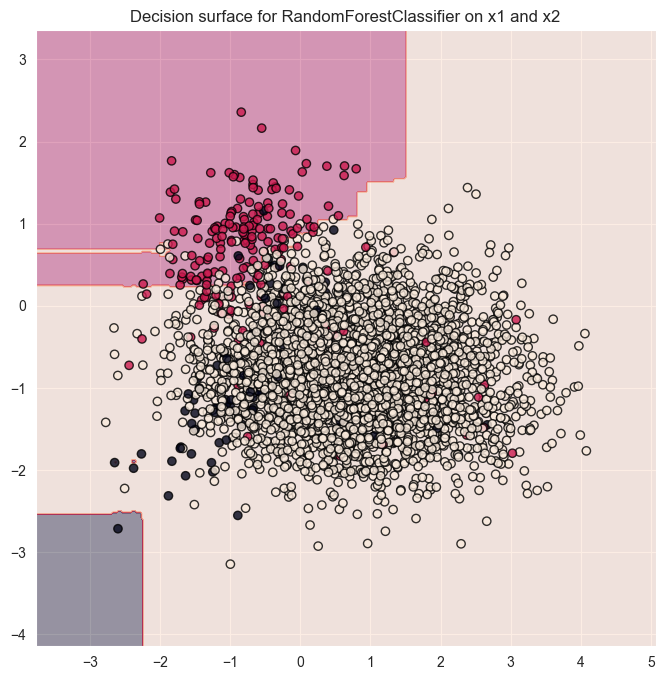

In [58]:
fig, ax = plt.subplots(figsize=(8,8))
get_decision_boundary(X_train, y_train, features = ['x1', 'x2' ], ax=ax, model="tree")

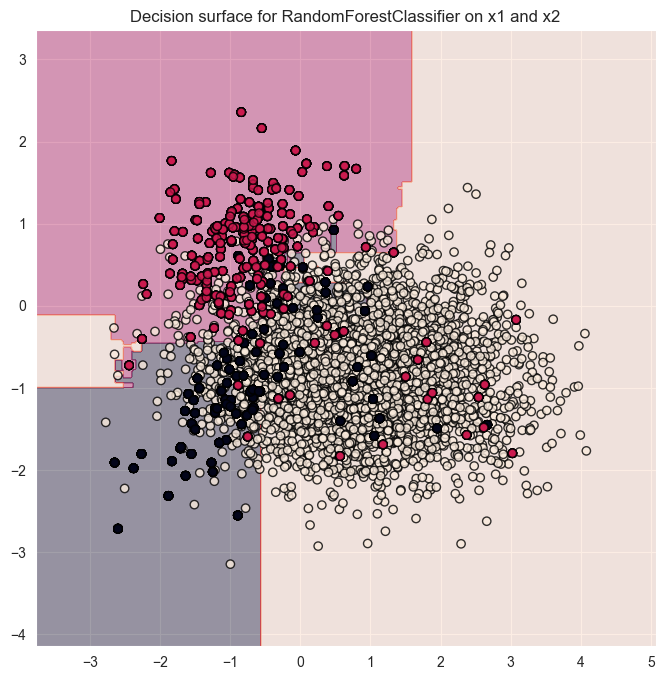

In [59]:

get_decision_boundary(X_resampled, y_resampled, features = ['x1', 'x2' ], model="tree")

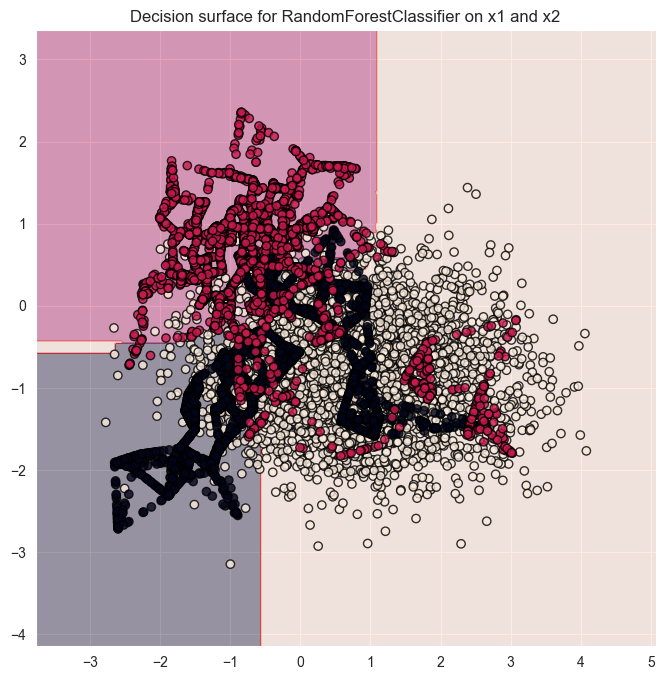

In [60]:
smote = SMOTE(random_state=SEED, k_neighbors=4)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
get_decision_boundary(X_resampled, y_resampled, features = ['x1', 'x2' ], model="tree")

К сожалению, SMOTE тяготеет к генерации дубликатов, не учитывает свойства распределений классов и неустойчив к шуму. К тому же, он может генерировать невозможные примеры. 

Введем еще один метод оверсемплинга - AdaSYN (Adaptive Synthetic). Этот алгоритм, в отличие от ресэмплинга и SMOTE позволяет сгенерировать более "сложные" примеры.
Этот алгоритм работает следующим образом:
1) Рассчитывается отношение миноритарного и мажоритарного класса: $d = m_s / m_l $
2) Определяется, сколько элементов необходимо нагенерировать: $G = (m_l - m_s) * \beta $. $\beta $ - параметр балансировки
3) Для каждого семпла из миноритарного класса находятся k соседей. После чего ему присваивается вес $r_i = num\_major\_neighbours / k $.
4) $r_i$ нормализуются так, чтобы их сумма равнялсь 1: $ {r_i}' =  \frac {r_i} {\sum{r_j}}$
5) Для каждого семпла определяется число сгененрированных примеров.  $G_i = G * {r_i}' $. Вопрос: в каких областях будет генерироваться больше примеров?
6) Далее для каждого примера и его соседей генерируется синтетический пример, как в SMOTE. Также может быть использована добавка белого шума.

Вопрос: какие минусы у SMOTE и AdaSYN по отношению друг к другу?

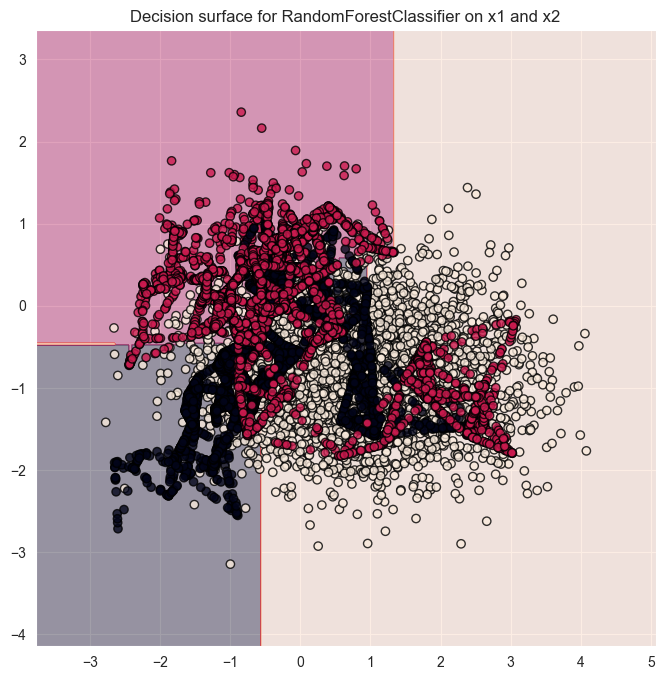

In [61]:
from imblearn.over_sampling import ADASYN
smote = ADASYN(random_state=SEED) # your parameters
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
get_decision_boundary(X_resampled, y_resampled, features = ['x1', 'x2' ], model="tree")

На графике сразу видно, когда AdaSYN  может помешать хорошей генерации. Как видно, так как AdaSYN концентрирует сгенерированные примеры у границ классов, тогда как SMOTE может "соединять" и примеры в центральной части класса, то он может быть более удачным методом. К тому же, сущестуют различные вариации SMOTE, которые могут давать хороший рещультат в такой постановке.

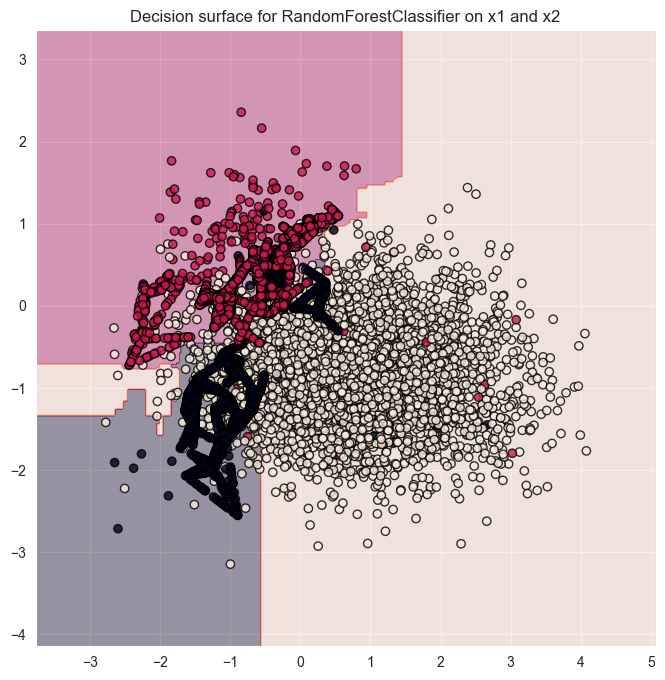

In [62]:
from imblearn.over_sampling import BorderlineSMOTE
smote = BorderlineSMOTE(random_state=SEED) # your parameters
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
get_decision_boundary(X_resampled, y_resampled, features = ['x1', 'x2' ], model="tree")

Для того, чтобы бороться с шумом и невозможными семплами, можно добавить фильтры, объединить SMOTE с кластерингом ( и потом генерировать семплы в рамках кластера).

Вопрос: какие можно еще придумать более "умные" варианты оверсемплинга на основе CMOTE?

### Ответ: более «умные» варианты оверсемплинга на основе SMOTE

Идеи расширения SMOTE, направленные на устранение его недостатков:

1. **SMOTE + Tomek Links / ENN** (`SMOTETomek`, `SMOTEENN`): после оверсемплинга применяем
   андерсемплинг для удаления шумных и пограничных точек. Устраняет синтетику, попавшую
   в «неправильную» область.

2. **Cluster-SMOTE**: разбиваем минорный класс на кластеры (KMeans), генерируем синтетику
   только *внутри* каждого кластера. Не интерполируем через кластерные границы → меньше
   «невозможных» объектов.

3. **SMOTE c kD-деревом по смешанным признакам** (`SMOTENC`): стандартный SMOTE
   работает только с числовыми признаками. SMOTENC корректно обрабатывает смешанные
   (численные + категориальные) данные.

4. **SWIM (Similarity-Weighted Interpolation)**: вместо случайного выбора соседей
   для интерполяции взвешиваем их по схожести с объектом → синтетика ближе к реальным
   данным минорного класса.

## Уменьшение выборки (андерсемплинг)

### Prototype generation
Методы Prototype generation (создания прототипов) позволяют сократить количество объектов в целевых классах, но остальные объектов генерируются, а не выбираются, из исходного набора.
ClusterCentroids использует для этого KMeans.

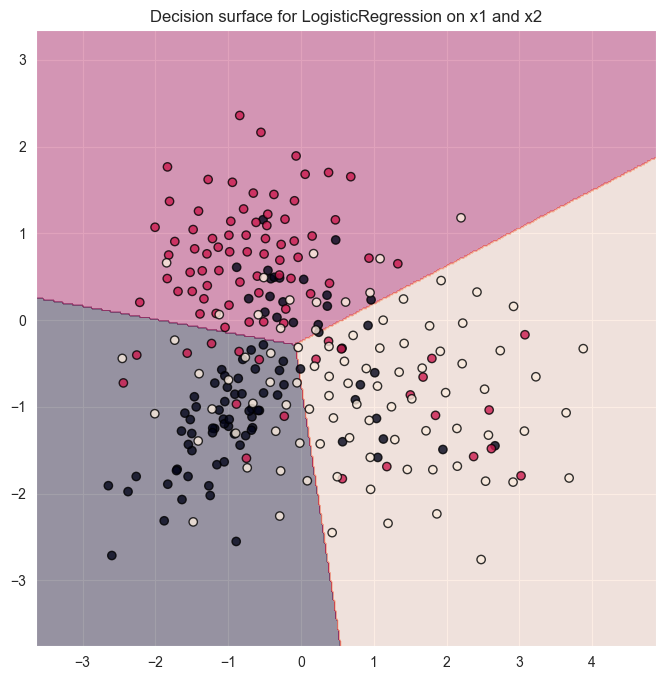

In [63]:
from sklearn.cluster import MiniBatchKMeans
from imblearn.under_sampling import ClusterCentroids
sampler = ClusterCentroids(random_state=SEED, estimator=KMeans())# your parameters)
X_resampled, y_resampled = sampler.fit_resample(X_train, y_train)
get_decision_boundary(X_resampled, y_resampled, features = ['x1', 'x2' ])

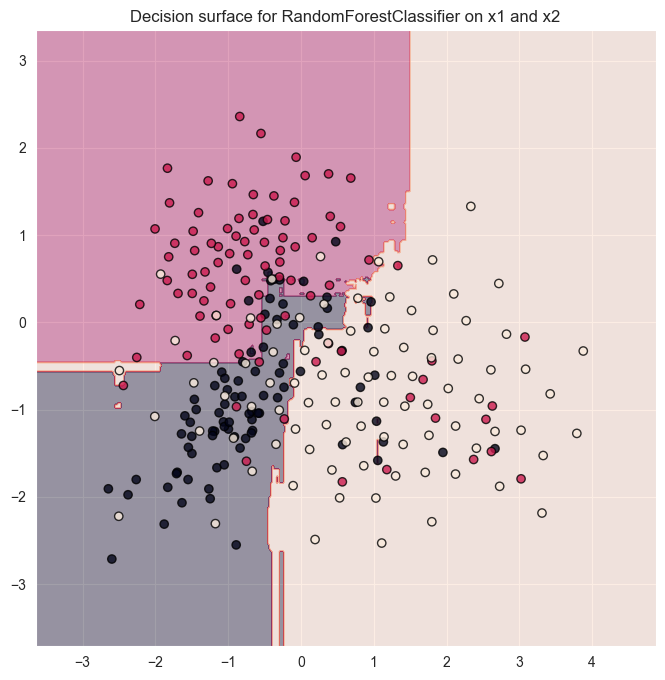

In [64]:
from imblearn.under_sampling import ClusterCentroids
sampler = ClusterCentroids(random_state=SEED, estimator=KMeans())# your parameters)
X_resampled, y_resampled = sampler.fit_resample(X_train, y_train)
get_decision_boundary(X_resampled, y_resampled, features = ['x1', 'x2' ], model="tree")

### Prototype selection
Алгоритмы Prototype selection (выбора прототипов) можно разделить на две группы: (i) методы контролируемой недостаточной выборки и (ii) методы очистки недостаточной выборки.

Методы контролируемой недостаточной выборки сокращают количество примеров в мажоритарных классах до произвольного размера. Обычно они сводят количество наблюдений к размеру миноритарного класса(ов).
К ним относятся: Random UnderSampling, NearMiss.
Напротив, методы очистки недостаточной выборки «очищают» пространство признаков, удаляя либо «зашумленные», либо «слишком легко классифицируемые» наблюдения, в зависимости от метода. Окончательное количество наблюдений в каждом классе зависит от метода очистки и не может быть указано пользователем.
К ним относится, например, метод связей Томека.


Наиболее простой метод - RandomUnderSampler - просто выкидывает семплы случайным образом.

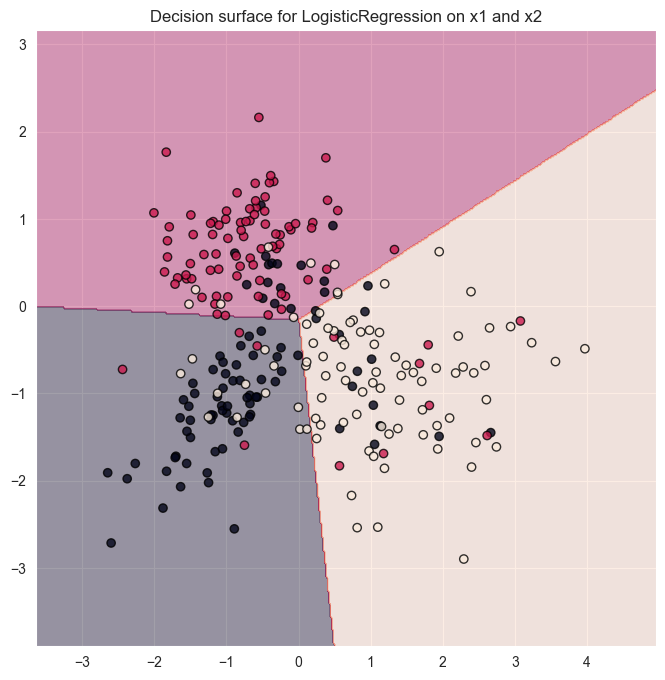

In [65]:
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(random_state=0)
X_resampled, y_resampled = rus.fit_resample(X_train, y_train)
get_decision_boundary(X_resampled, y_resampled, features = ['x1', 'x2' ])


Задание: попробуйте реализовать такой семплер вручную:

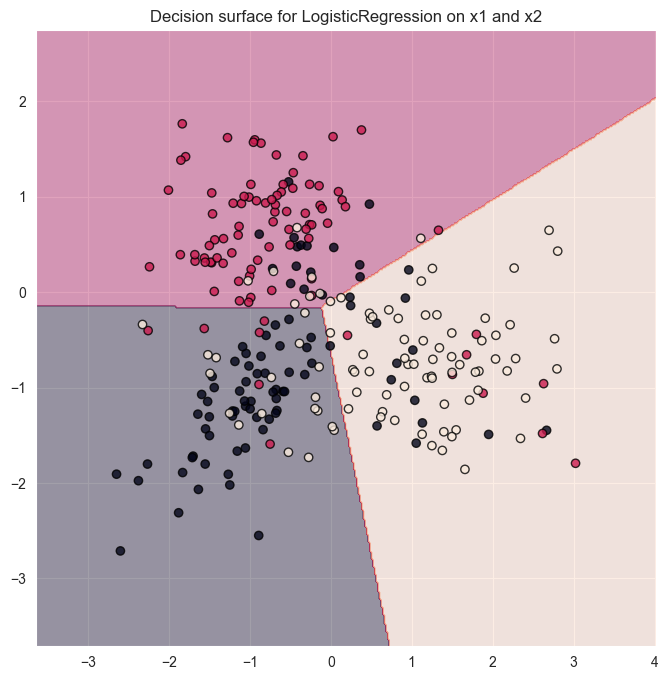

In [66]:
rng = np.random.RandomState(0)
classes = np.unique(np.asarray(y_train))
target = min([np.sum(np.asarray(y_train) == c) for c in classes])
idx = [rng.choice(np.where(np.asarray(y_train) == c)[0], size=target, replace=False) for c in classes]
idx = np.concatenate(idx)
X_resampled = np.asarray(X_train)[idx]
y_resampled = np.asarray(y_train)[idx]
get_decision_boundary(X_resampled, y_resampled, features=['x1', 'x2'])


NearMiss добавляет некоторые эвристики для выбора семплов. Так, он может выбирать для удаления примеры, ближайшие к миноритарном классу: 
NearMiss-1 выбирает примеры, у которых наименьшее среднее расстояние до **ближайших** N примеров из миноритарного класса, а NearMiss-2 - среднее расстояние у которых до наиболее **дальних** примеров из миноритарного класса наименьшее.

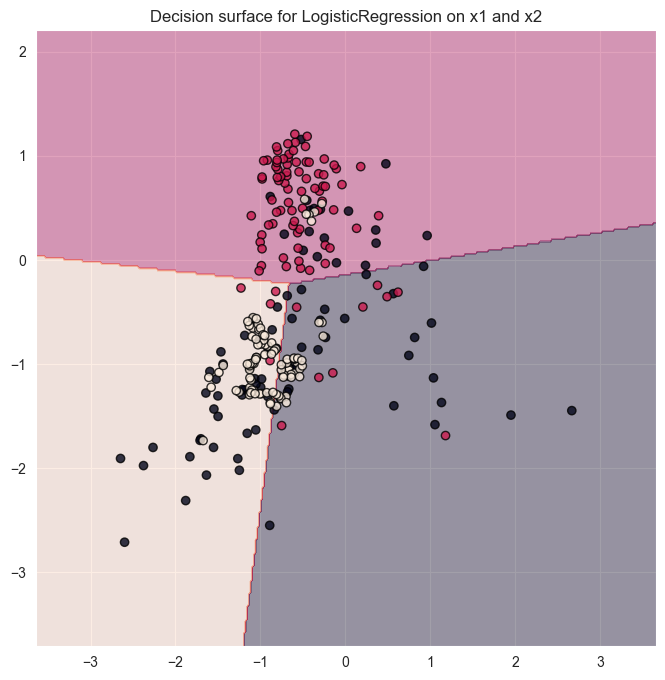

In [67]:
from imblearn.under_sampling import NearMiss
nm = NearMiss(version=1, n_neighbors=3)
X_resampled, y_resampled = nm.fit_resample(X_train, y_train)
get_decision_boundary(X_resampled, y_resampled, features=['x1', 'x2'])


Связь Томека существует, когда два примера из разных классов являются ближайшими соседями друг к другу. Алгоритм связей Томека детектирует такие связи и удаляет пример из мажоритарного класса. Основная идея заключается в том, что связи Томека зашумлены или наблюдения трудно классифицировать, и поэтому они не помогут алгоритму найти подходящую границу разделения.


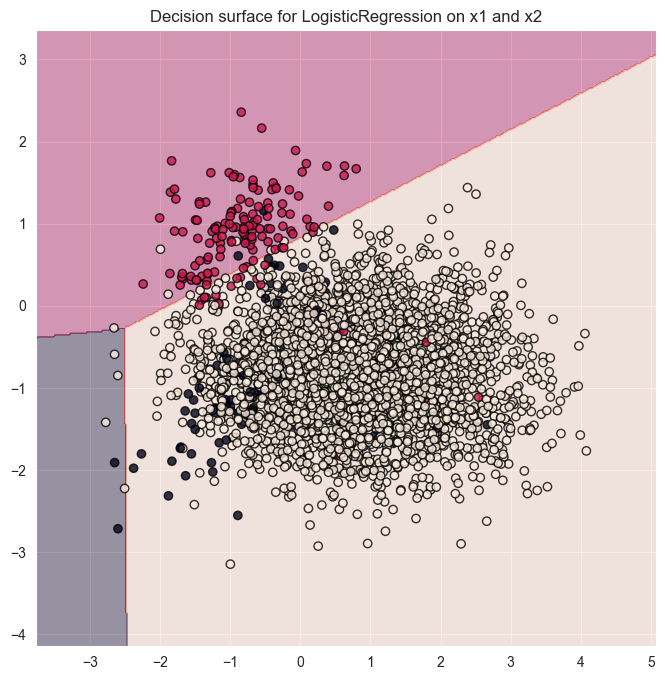

In [68]:
from imblearn.under_sampling import TomekLinks
tl = TomekLinks()
X_resampled, y_resampled = tl.fit_resample(X_train, y_train)
get_decision_boundary(X_resampled, y_resampled, features=['x1', 'x2'])


Edited nearest neighbours - для примеров из миноритарного класса находит k ближайших соседей и удаляет все семплы из мажоритарных классов, попавшие в эту окрестность.

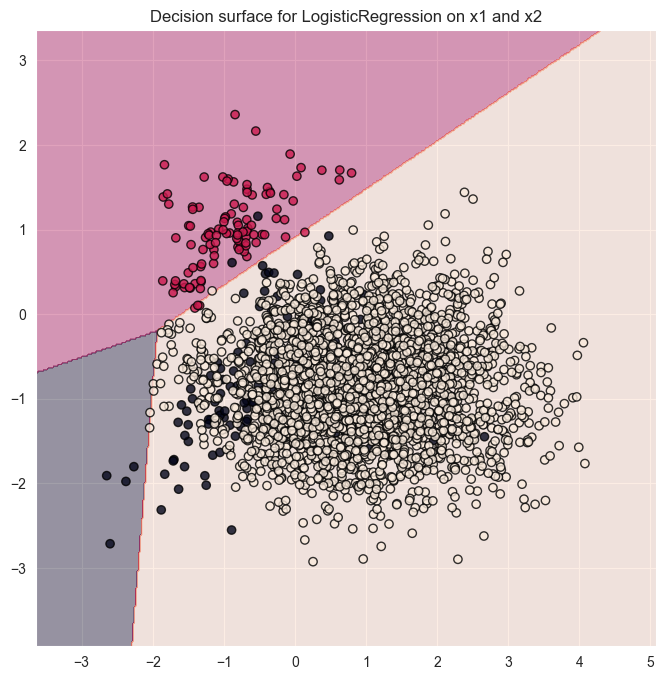

In [69]:
from imblearn.under_sampling import EditedNearestNeighbours
enn = EditedNearestNeighbours(n_neighbors=3, kind_sel='all')
X_resampled, y_resampled = enn.fit_resample(X_train, y_train)
get_decision_boundary(X_resampled, y_resampled, features=['x1', 'x2'])


Нетрудно заметить, что балансировка лосса - более общая идея по отношению к оверсемплингу и андерсемплингу, при этом и гораздо более легкая в использовании. Однако идея генерации синтетики для улучшения качества модели жива и принимает разные формы. 

## Выбор порога

Как мы уже видели в ноутбуке про калибровку, хорошая модель на самом деле должна давать вероятности классов близкие к реальным. При этом метрики считаются для бинаризхованных предсказаний и могут мало соответствовать реальности. Но порог можно подбирать, простейшая стратегия - на кросс-валидации. 

In [70]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, log_loss, roc_auc_score, average_precision_score
from sklearn.model_selection import cross_val_predict

def investigate_model(model, X, y, X_test, y_test, use_cv: bool = True,  cv: int = 10):
    """
    оценить стратегию подбора порога
    """
    df = pd.DataFrame(index=['train', 'test0', 'cv', 'test', 'theta'])
    # качество бинаризации
    metrics = [accuracy_score, balanced_accuracy_score, f1_score]
    # качество оценок
    metrics2 = [log_loss, roc_auc_score, average_precision_score]

    # на cv
    if use_cv:
        a_cv = cross_val_predict(model, X, y, cv=cv, method='predict_proba')[:,1]

    model.fit(X, y)
    
    a_train = model.predict_proba(X)[:,1]
    b_train = model.predict(X)

    a_test = model.predict_proba(X_test)[:,1]
    b_test = model.predict(X_test)
    
    # оптимальный порог по cv
    thetas = np.linspace(0, 1, 101)
    for metric in metrics:
        best_t = 0.5
        if use_cv:
            q = np.array([metric(y, a_cv > t) for t in thetas])
            i = np.argmax(q)
            best_t = thetas[i]
            s_cv = q[i]
            s_test = metric(y_test, a_test > best_t)
        else:
            s_cv = np.nan
            s_test = metric(y_test, b_test)
        sb_train = metric(y, b_train)
        sb_test = metric(y_test, b_test)
        df[metric.__name__] = [sb_train, sb_test, s_cv, s_test, best_t]

    for metric in metrics2:
        sb_train = metric(y, a_train)
        sb_test = metric(y_test, a_test)
        if use_cv:
            s_cv = metric(y, a_cv)

        df[metric.__name__] = [sb_train, sb_test, s_cv, sb_test, np.nan]
    return (df)


In [71]:
X = df.drop('quality', axis=1)
y = df['quality']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
_, _, y_train_b, y_test_b = train_test_split(X, y_binarized, test_size=0.2, random_state=SEED)


In [72]:
dfs = []  # для создания отчётности

model   = RandomForestClassifier(max_depth=5)
model_w = RandomForestClassifier(max_depth=5, class_weight='balanced')

# --- Оригинал ---
dfs.append(investigate_model(model,   X_train, y_train_b, X_test, y_test_b, use_cv=False))

# --- Балансировка весами ---
dfs.append(investigate_model(model_w, X_train, y_train_b, X_test, y_test_b, use_cv=False))

# --- С подбором порога (CV) ---
dfs.append(investigate_model(model,   X_train, y_train_b, X_test, y_test_b))
dfs.append(investigate_model(model_w, X_train, y_train_b, X_test, y_test_b))

# --- С оверсемплингом ---
minority_count = int(min(np.bincount(np.asarray(y_train_b))))
k_nb = max(1, min(3, minority_count - 1))

over_techniques = [
    ('Over:RandomOverSampler', RandomOverSampler(random_state=SEED)),
    ('Over:SMOTE',             SMOTE(random_state=SEED, k_neighbors=k_nb)),
    ('Over:ADASYN',            ADASYN(random_state=SEED, n_neighbors=k_nb)),
]

for name, sampler in over_techniques:
    X_res, y_res = sampler.fit_resample(X_train, y_train_b)
    m = RandomForestClassifier(max_depth=5, random_state=SEED)
    dfs.append(investigate_model(m, X_res, y_res, X_test, y_test_b, use_cv=False))

# --- С андерсемплингом ---
under_techniques = [
    ('Under:RandomUnderSampler',       RandomUnderSampler(random_state=SEED)),
    ('Under:NearMiss-1',               NearMiss(version=1, n_neighbors=k_nb)),
    ('Under:NearMiss-2',               NearMiss(version=2, n_neighbors=k_nb)),
    ('Under:TomekLinks',               TomekLinks()),
    ('Under:EditedNearestNeighbours',  EditedNearestNeighbours(n_neighbors=k_nb)),
]

for name, sampler in under_techniques:
    X_res, y_res = sampler.fit_resample(X_train, y_train_b)
    m = RandomForestClassifier(max_depth=5, random_state=SEED)
    dfs.append(investigate_model(m, X_res, y_res, X_test, y_test_b, use_cv=False))

# Ключи для итоговой таблицы
keys = (['Original', 'Weights', 'Threshold', 'Threshold+Weights']
        + [n for n, _ in over_techniques]
        + [n for n, _ in under_techniques])

d = pd.concat([df_.T['test'] for df_ in dfs], keys=keys, axis=1).round(3)
d.loc['log_loss', :] = -d.loc['log_loss', :]
d = d.rename(index={'log_loss': '-log_loss'})
display(d.style.highlight_max(axis=1))


,Original,Weights,Threshold,Threshold+Weights,Over:RandomOverSampler,Over:SMOTE,Over:ADASYN,Under:RandomUnderSampler,Under:NearMiss-1,Under:NearMiss-2,Under:TomekLinks,Under:EditedNearestNeighbours
accuracy_score,0.862000,0.825000,0.859000,0.878000,0.828000,0.812000,0.788000,0.778000,0.612000,0.447000,0.859000,0.850000
balanced_accuracy_score,0.610000,0.763000,0.804000,0.788000,0.798000,0.756000,0.741000,0.794000,0.663000,0.657000,0.633000,0.669000
f1_score,0.353000,0.541000,0.547000,0.547000,0.574000,0.524000,0.493000,0.530000,0.367000,0.347000,0.400000,0.455000
-log_loss,-0.311000,-0.345000,-0.302000,-0.344000,-0.372000,-0.393000,-0.402000,-0.453000,-0.685000,-1.111000,-0.311000,-0.317000
roc_auc_score,0.851000,0.871000,0.865000,0.874000,0.875000,0.844000,0.840000,0.861000,0.731000,0.830000,0.852000,0.851000
average_precision_score,0.571000,0.638000,0.589000,0.653000,0.639000,0.537000,0.553000,0.601000,0.376000,0.488000,0.568000,0.532000


In [73]:
keys = ['Original', 'Weights', 'Threshold', 'Threshold + Weights']
d = pd.concat([d.T['test'] for d in dfs], keys=keys, axis=1).round(3)
d.loc['log_loss',:] = -d.loc['log_loss',:]
d = d.rename(index={'log_loss':'-log_loss'})

d.style.highlight_max(axis=1, color='#FFDDDD')

C:\Users\Roman\AppData\Local\Temp\ipykernel_18980\648731095.py:2: FutureWarning: The behavior of pd.concat with len(keys) != len(objs) is deprecated. In a future version this will raise instead of truncating to the smaller of the two sequences
  d = pd.concat([d.T['test'] for d in dfs], keys=keys, axis=1).round(3)


,Original,Weights,Threshold,Threshold + Weights
accuracy_score,0.862000,0.825000,0.859000,0.878000
balanced_accuracy_score,0.610000,0.763000,0.804000,0.788000
f1_score,0.353000,0.541000,0.547000,0.547000
-log_loss,-0.311000,-0.345000,-0.302000,-0.344000
roc_auc_score,0.851000,0.871000,0.865000,0.874000
average_precision_score,0.571000,0.638000,0.589000,0.653000


Подбор порога (без совмещения с любой другой техникой) – идеальная стратегия для «нешумных данных» (проверьте на синтетике!).  

Если данные простые, модель хорошо откалибрована, это и надо использовать. 

Если же в данных присутствует шум, и посторить хорошие признаки при доступных данных сложно, то семплинг может помочь, хотя и другого вида (аугментации, балансировка батчей, negative sampling). 

Если данных очень много, а дисбаланс большой, можно попробовать методы андерсемплинга, но сравнивая на отдельно м стратифицированном фолде. 


Задание: Изучите также matthews_corrcoef, cohen_kappa_score. Постройте графики для них, зачем они нужны? Являются ли они сбалансированными (дают ли сбаланчированную оценку, если есть существенный дисбаланс)? 

Задание: оцените качество моделей с семплингом

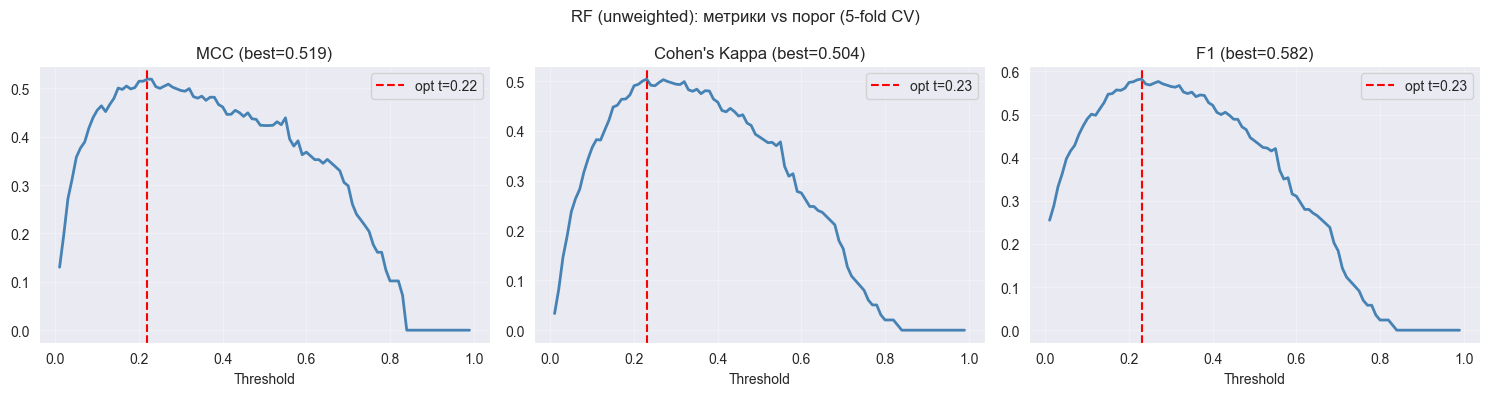

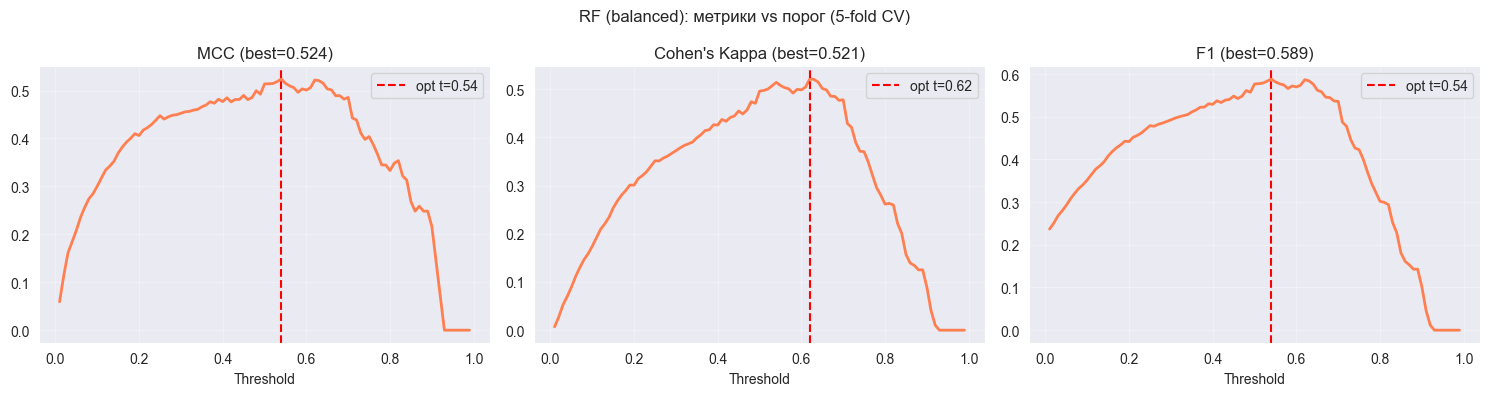

=== Что такое MCC и Cohen Kappa? ===

Matthews Correlation Coefficient (MCC):
  MCC = (TP*TN - FP*FN) / sqrt((TP+FP)(TP+FN)(TN+FP)(TN+FN))
  Диапазон: [-1, +1]. +1 — идеал, 0 — случайный классификатор, -1 — антиклассификатор.
  Учитывает все 4 значения матрицы ошибок симметрично — устойчив к дисбалансу.
  Не зависит от того, какой класс «позитивный» (в отличие от F1/Precision/Recall).

Cohen's Kappa Score:
  κ = (p_o - p_e) / (1 - p_e)
  p_o = observed accuracy, p_e = expected accuracy случайного классификатора.
  Диапазон: (-inf, 1]. +1 — идеал, 0 — не лучше случайного, <0 — хуже случайного.
  Учитывает вероятность случайного совпадения — более консервативен, чем accuracy.

Являются ли они threshold-invariant?
  Нет — и MCC, и Kappa зависят от порога: они считаются по бинаризованным
  предсказаниям. Threshold-invariant метрики: ROC-AUC, Average Precision (PR-AUC).

Сбалансированы ли они при дисбалансе?
  Да — обе метрики учитывают все 4 клетки матрицы ошибок и не завышают оценку
  при

In [74]:
# Задание: matthews_corrcoef и cohen_kappa_score — графики vs порог
from sklearn.metrics import matthews_corrcoef, cohen_kappa_score

model_mcc   = RandomForestClassifier(max_depth=5, random_state=SEED)
model_mcc_w = RandomForestClassifier(max_depth=5, class_weight='balanced', random_state=SEED)

for m, title, color in [
    (model_mcc,   'RF (unweighted)', 'steelblue'),
    (model_mcc_w, 'RF (balanced)',   'coral'),
]:
    from sklearn.model_selection import cross_val_predict
    proba_cv = cross_val_predict(m, X_train, y_train_b, cv=5, method='predict_proba')[:, 1]

    thresholds = np.linspace(0.01, 0.99, 99)
    mcc_scores   = []
    kappa_scores = []
    f1_scores    = []

    for t in thresholds:
        preds = (proba_cv > t).astype(int)
        mcc_scores.append(matthews_corrcoef(y_train_b, preds))
        kappa_scores.append(cohen_kappa_score(y_train_b, preds))
        f1_scores.append(f1_score(y_train_b, preds, zero_division=0))

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f'{title}: метрики vs порог (5-fold CV)', fontsize=12)

    for ax, scores, name in zip(axes,
            [mcc_scores, kappa_scores, f1_scores],
            ['MCC', "Cohen's Kappa", 'F1']):
        ax.plot(thresholds, scores, color=color, lw=2)
        best_t = thresholds[int(np.argmax(scores))]
        ax.axvline(best_t, color='red', ls='--', label=f'opt t={best_t:.2f}')
        ax.set_title(f'{name} (best={max(scores):.3f})')
        ax.set_xlabel('Threshold'); ax.legend(); ax.grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()

print('=== Что такое MCC и Cohen Kappa? ===')
print()
print('Matthews Correlation Coefficient (MCC):')
print('  MCC = (TP*TN - FP*FN) / sqrt((TP+FP)(TP+FN)(TN+FP)(TN+FN))')
print('  Диапазон: [-1, +1]. +1 — идеал, 0 — случайный классификатор, -1 — антиклассификатор.')
print('  Учитывает все 4 значения матрицы ошибок симметрично — устойчив к дисбалансу.')
print('  Не зависит от того, какой класс «позитивный» (в отличие от F1/Precision/Recall).')
print()
print("Cohen's Kappa Score:")
print('  κ = (p_o - p_e) / (1 - p_e)')
print('  p_o = observed accuracy, p_e = expected accuracy случайного классификатора.')
print('  Диапазон: (-inf, 1]. +1 — идеал, 0 — не лучше случайного, <0 — хуже случайного.')
print('  Учитывает вероятность случайного совпадения — более консервативен, чем accuracy.')
print()
print('Являются ли они threshold-invariant?')
print('  Нет — и MCC, и Kappa зависят от порога: они считаются по бинаризованным')
print('  предсказаниям. Threshold-invariant метрики: ROC-AUC, Average Precision (PR-AUC).')
print()
print('Сбалансированы ли они при дисбалансе?')
print('  Да — обе метрики учитывают все 4 клетки матрицы ошибок и не завышают оценку')
print('  при дисбалансе (в отличие от accuracy и micro F1).')


In [75]:

def plot_metrics_vs_threshold(
    model,
    X,
    y,
    X_val=None,
    y_val=None,
    use_cv=True,
    cv=10,
    thresholds=np.linspace(0, 1, 101),
    figsize=(12, 4),
    title_prefix=""
):
    if use_cv:
        proba_val = cross_val_predict(model, X, y, cv=cv, method='predict_proba')[:, 1]
        y_val = y  # метки те же, что и для обучения (кросс-валидация даёт честные предсказания)
    else:
        model.fit(X, y)
        proba_val = model.predict_proba(X_val)[:, 1]

    metrics = [accuracy_score, balanced_accuracy_score, f1_score]
    metric_names = [m.__name__ for m in metrics]
    scores = {name: [] for name in metric_names}
    
    for t in thresholds:
        preds = (proba_val > t).astype(int)
        for m, name in zip(metrics, metric_names):
            scores[name].append(m(y_val, preds))
    
    fig, axes = plt.subplots(1, 3, figsize=figsize, sharey=True)
    for ax, name in zip(axes, metric_names):
        ax.plot(thresholds, scores[name], label=name, color='blue')
        best_idx = np.argmax(scores[name])
        best_t = thresholds[best_idx]
        best_val = scores[name][best_idx]
        ax.axvline(best_t, color='red', linestyle='--', label=f'opt = {best_t:.3f}')
        ax.set_title(f'{name}\nopt value = {best_val:.3f}')
        ax.set_xlabel('threshold')
        ax.set_ylabel('score')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.suptitle(f"{title_prefix}Зависимость метрик от порога", y=1.05)
    plt.tight_layout()
    plt.show()

Посмотрим, как меняются метрики при выборе порога.

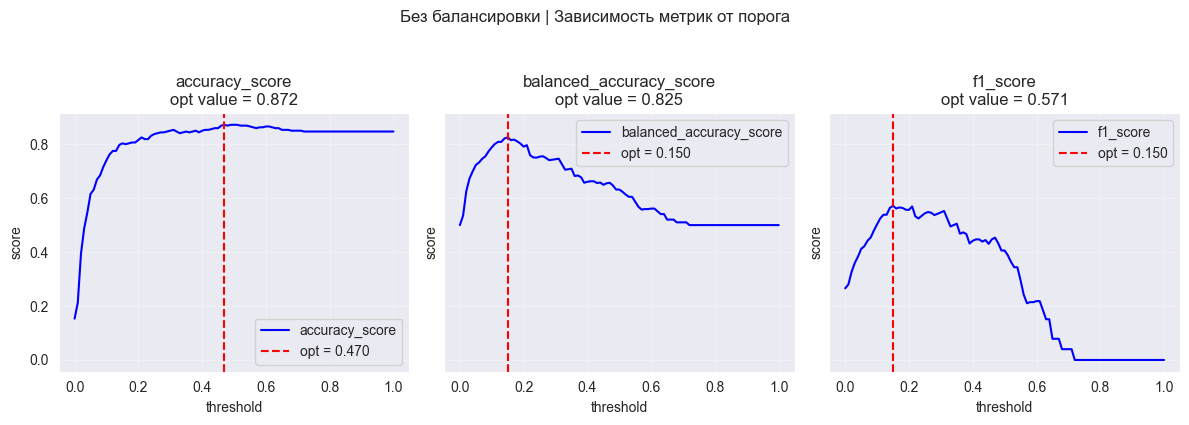

In [76]:

model = RandomForestClassifier(max_depth=5)
model_w =  RandomForestClassifier(max_depth=5, class_weight='balanced')

plot_metrics_vs_threshold(
    model, X_train, y_train_b, X_val=X_test, y_val=y_test_b,
    use_cv=False, title_prefix="Без балансировки | "
)


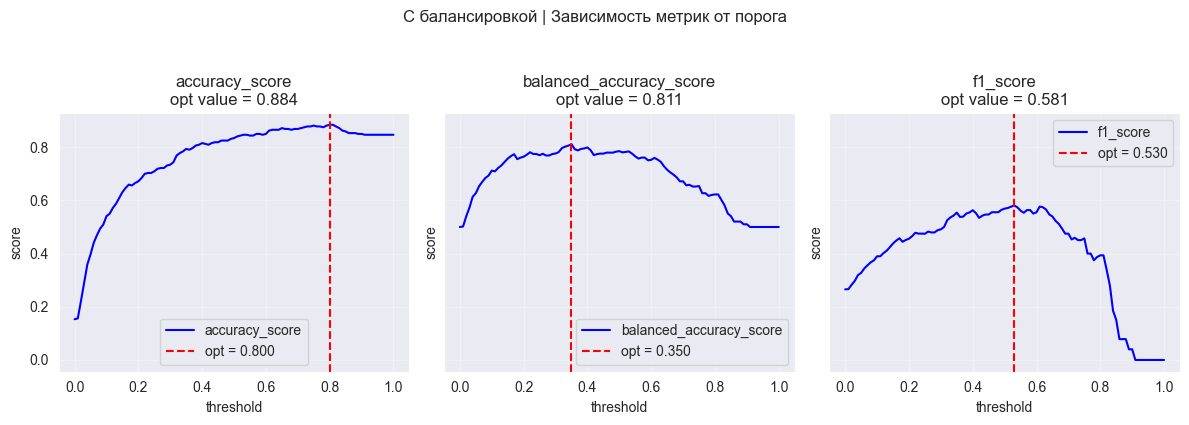

In [77]:

plot_metrics_vs_threshold(
    model_w, X_train, y_train_b, X_val=X_test, y_val=y_test_b,
    use_cv=False, title_prefix="С балансировкой | "
)


Как видно, после балансировки графики более "растянутые", при этом оптимальные пороги правее исходных. Почему это логично?

### Ответ: почему после балансировки оптимальные пороги правее?

После балансировки весов модель обучается так, чтобы штрафовать за ошибки на редком классе
сильнее. Это приводит к тому, что модель *повышает* предсказанные вероятности для
миноритарного (позитивного) класса — она «осторожнее» и чаще предсказывает «1».

**Последствие**: предсказанные вероятности смещаются вправо (к 1). Если у исходной модели
медиана $\hat{p}$ была, например, 0.3, то у сбалансированной — 0.5 или выше.

**Почему оптимальный порог тоже правее?**

Потому что при сдвинутых вероятностях порог 0.5 начинает предсказывать «1» слишком часто,
что увеличивает FP. Чтобы вернуть оптимальное соотношение Precision/Recall,
нужно поднять порог — то есть стать «строже» при вынесении положительного решения.

**Это логично**: сбалансированная модель хорошо откалибрована относительно нового
распределения (равного по классам). Но реальные данные несбалансированы, поэтому
нужна поправка порогом обратно — и оптимальный порог сдвигается вправо от 0.5.

**Практический вывод**: балансировка весов и подбор порога — взаимодополняющие техники.
Балансировка улучшает recall на редком классе, подбор порога — точно настраивает
трейдофф precision/recall под конкретную задачу.